In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_gmsh_mesh,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3

In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'wrench_extrude'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# # Material
# Steel=Material( name='Steel',
#                 E=2000,
#                 nu=0.30,
#                 rho=1.25*tf/m**3*0)

# # Sections
# F1=Membrane(    name='F1',
#                 thickness=15,
#                 material=Steel)

# # Dictionaries
# section_dictionary={274:F1,
#                         }

# restrain_dictionary={275:['r', 'r' , 'r'] , 
#                      277: ['f' , 'f' , 'r']}

load_dictionary = {
                257:   {'value': 4, 'direction': '-y'},     
}

In [6]:
# Read mesh
mesh = GMSHtools(output_file)

system_nDof = mesh.system_nDof
node_map = mesh.node_map


  MESH SUMMARY

  === NODES ===  (2774 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1       -46.1557        13.3333         0.0000
       2       -46.1557       -13.3333         0.0000
       3        45.5761       -11.0200         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (7 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     256      1   'Support'
     257      1   'LoadBoundary'
     252      2   'Cabeza_5mm_der'
     253      2   'Cabeza_5mm_izq'
     254      2   'Mango_3mm'
     255      2   'Mango_1_6mm'
     364      3   'solido'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (7 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
---------------------------

In [7]:
# remove floating nodes
connected_nodes = set()
for group in mesh.elements.values():
    for conn in group['connectivity']:
        connected_nodes.update(conn)

floating = set(mesh.nodes.keys()) - connected_nodes
for tag in floating:
    del mesh.nodes[tag]
print(f"Removed {len(floating)} floating nodes: {floating}")

# recalculate node_map and system_nDof
from fem.utils.functions import plan
mesh.node_map, mesh.system_nDof = plan(mesh)

node_map    = mesh.node_map
system_nDof = mesh.system_nDof

Removed 0 floating nodes: set()


In [8]:
# build lumped nodal force vector
F_nodal = mesh.build_load_vector(load_dictionary)

# assemble to global vector
F_load = np.zeros(mesh.system_nDof)
for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
F_load[np.abs(F_load) < 1e-4] = 0.0

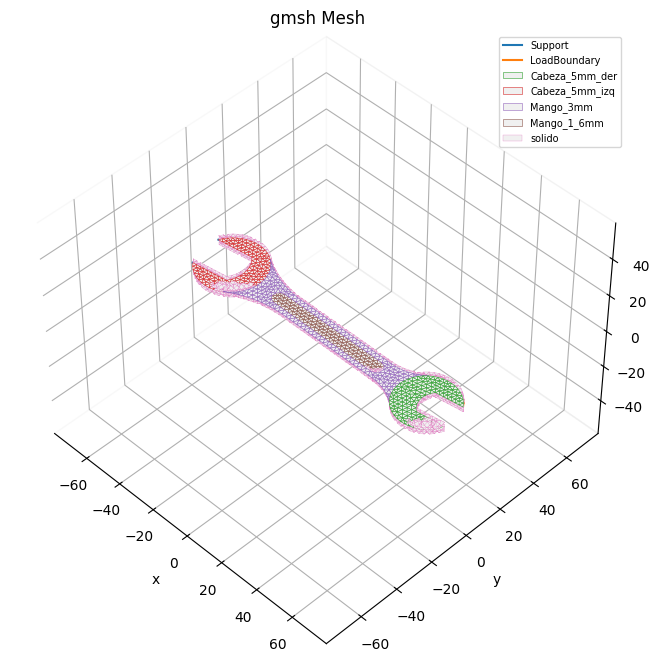

In [9]:
# %matplotlib widget

plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
               view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

## Opensees

In [10]:
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruno4ever *********** 3.7.2




In [11]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y , z)

In [12]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['Support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [13]:
# Material
E = 3500      
nu = 0.36     
ops.nDMaterial('ElasticIsotropic', 1, E, nu)


In [14]:
group = mesh.physical_groups['solido'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3, n4 = conn
    ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

In [15]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [16]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
for tag, force in F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [17]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

In [18]:
# opsv.plot_defo(
#     sfac=10,
#     fig_wi_he=(50, 25),
#     endDispFlag=True,
#     unDefoFlag=0
# )

In [19]:
n_nodes = len(mesh.nodes)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

ops.reactions()

for i, (tag, coords) in enumerate(mesh.nodes.items()):
    u_3d[i, 0]  = ops.nodeDisp(tag, 1)
    u_3d[i, 1]  = ops.nodeDisp(tag, 2)
    u_3d[i, 2]  = ops.nodeDisp(tag, 3)
    F_3d[i, 0]  = ops.nodeUnbalance(tag, 1)
    F_3d[i, 1]  = ops.nodeUnbalance(tag, 2)
    F_3d[i, 2]  = ops.nodeUnbalance(tag, 3)
    R_3d[i, 0]  = ops.nodeReaction(tag, 1)
    R_3d[i, 1]  = ops.nodeReaction(tag, 2)
    R_3d[i, 2]  = ops.nodeReaction(tag, 3)

# Node tags for Gmsh
node_tags = np.array(list(mesh.nodes.keys()))

# Element tags and stresses
element_tags_list = mesh.physical_groups['solido'].elements['element_tags']
n_elements        = len(element_tags_list)

sigma_gmsh     = np.zeros((n_elements, 3))
von_mises_gmsh = np.zeros(n_elements)

for i, elem_tag in enumerate(element_tags_list):
    stress = ops.eleResponse(elem_tag, 'stresses')
    if stress:
        s   = np.array(stress).reshape(-1, 6)
        sxx = s[:, 0].mean()
        syy = s[:, 1].mean()
        sxy = s[:, 2].mean()
        sigma_gmsh[i, :]  = [sxx, syy, sxy]
        von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2 + 3*sxy**2)

In [20]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

view_disp_vec = add_node_data_view("Disp Vector", 
                                    node_tags, 
                                    u_3d, 
                                    visible=False)
u_mag = np.linalg.norm(u_3d, axis=1)


view_disp  = add_node_data_view("Displacements",
                   node_tags, 
                   u_mag,
                   deformed_view=view_disp_vec, 
                   factor=2)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

3

In [21]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])


6

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average   (mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 0]
                                    )
add_node_data_view("Sxx Nodal Averaged",
                   node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                sigma_gmsh[:, 1],   
                                )
add_node_data_view("Syy Nodal Averaged",                 
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                sigma_gmsh[:, 2],   
                                )
add_node_data_view("Sxy Nodal Averaged",                 
                    node_tags, sxy_nodal)


9

In [23]:

                   
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()